# Exploración de datos y preparación (Capa Plata)

En esta notebook trabajaremos con los datos de telemetría solar previamente almacenados por estación (Capa Bronce). El objetivo es transformar los datos crudos, consolidarlos, manejar fechas, explorar las distribuciones, tratar valores nulos y generar un dataset estructurado para la Capa Plata.

## Importación de librerías y configuración de paths

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

BASE_DIR = Path('..').resolve()
BRONCE_DIR = BASE_DIR / 'data' / 'bronce'
PLATA_DIR = BASE_DIR / 'data' / 'plata'

PLATA_DIR.mkdir(parents=True, exist_ok=True)
print("Directorios configurados correctamente.")

Directorios configurados correctamente.


## Carga de archivos de todas las estaciones

In [2]:
# Cargar todos los archivos CSV de la capa Bronce
archivos = list(BRONCE_DIR.rglob("*.csv"))

dfs = []
for archivo in archivos:
    df = pd.read_csv(archivo)
    dfs.append(df)

# Combinar en un único DataFrame
df_estaciones = pd.concat(dfs, ignore_index=True)
print(f"Total de registros cargados: {len(df_estaciones)}")
print(f"Estaciones presentes: {df_estaciones['station_name'].unique()}")
print(df_estaciones)

Total de registros cargados: 106872
Estaciones presentes: <StringArray>
[ 'AguasAgrias',      'Tosoabi',       'Crater',      'Cufinho',
      'Mallama',      'Limones',     'Barranco',       'LaMesa',
   'MundoNuevo',        'Bruma', 'MijitayoBajo',         'Coba',
        'Arles',      'Anganoy',   'PajaBlanca',      'SanJose',
  'Bordoncillo',      'Paisita',      'Consaca',         'Vivi',
  'SanCayetano', 'CruzAmarillo']
Length: 22, dtype: str
        station_name            timestamp  pv_voltage_V  pv_current_A  \
0        AguasAgrias  2026-05-12 10:06:22         20.56          1.50   
1        AguasAgrias  2026-05-12 10:17:11         21.14          1.22   
2        AguasAgrias  2026-05-12 10:28:11         21.94          1.11   
3        AguasAgrias  2026-05-12 10:39:06         19.83          1.31   
4        AguasAgrias  2026-05-12 10:49:54         21.59          1.38   
...              ...                  ...           ...           ...   
106867  CruzAmarillo  2026-06-20 10:

In [3]:
df_estaciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 106872 entries, 0 to 106871
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   station_name                 106872 non-null  str    
 1   timestamp                    106872 non-null  str    
 2   pv_voltage_V                 106167 non-null  float64
 3   pv_current_A                 106081 non-null  float64
 4   pv_power_W                   106003 non-null  float64
 5   battery_voltage_V            106007 non-null  float64
 6   battery_current_A            105983 non-null  float64
 7   battery_soc_%                105922 non-null  float64
 8   controller_temp_C            105850 non-null  float64
 9   charging_status              105826 non-null  float64
 10  load_current_A               105782 non-null  float64
 11  load_power_W                 105753 non-null  float64
 12  energy_generated_today_kWh   105751 non-null  float64
 13  energy_con

## Normalización de fechas

In [4]:
# Convertir timestamp a formato datetime de pandas
df_estaciones['timestamp'] = pd.to_datetime(df_estaciones['timestamp'])

# Ordenar por estación y por tiempo para garantizar coherencia temporal
df_estaciones = df_estaciones.sort_values(by=['station_name', 'timestamp']).reset_index(drop=True)

# Extraer la fecha sin hora para agrupaciones diarias posteriores
df_estaciones['fecha'] = pd.to_datetime(df_estaciones['timestamp'].dt.date)
df_estaciones['hora'] = df_estaciones['timestamp'].dt.hour
df_estaciones['minuto'] = df_estaciones['timestamp'].dt.minute

print("Fechas normalizadas. Tipos de datos actualizados:")
print(df_estaciones[['station_name', 'timestamp', 'fecha', 'hora', 'minuto']].dtypes)
print(df_estaciones[['station_name', 'timestamp', 'fecha', 'hora', 'minuto']].head)


Fechas normalizadas. Tipos de datos actualizados:
station_name               str
timestamp       datetime64[us]
fecha            datetime64[s]
hora                     int32
minuto                   int32
dtype: object
<bound method NDFrame.head of        station_name           timestamp      fecha  hora  minuto
0       AguasAgrias 2026-05-12 10:06:22 2026-05-12    10       6
1       AguasAgrias 2026-05-12 10:17:11 2026-05-12    10      17
2       AguasAgrias 2026-05-12 10:28:11 2026-05-12    10      28
3       AguasAgrias 2026-05-12 10:39:06 2026-05-12    10      39
4       AguasAgrias 2026-05-12 10:49:54 2026-05-12    10      49
...             ...                 ...        ...   ...     ...
106867         Vivi 2026-06-20 10:23:55 2026-06-20    10      23
106868         Vivi 2026-06-20 10:35:48 2026-06-20    10      35
106869         Vivi 2026-06-20 10:47:45 2026-06-20    10      47
106870         Vivi 2026-06-20 10:59:52 2026-06-20    10      59
106871         Vivi 2026-06-20 11:12

## Tratamiento inicial de valores nulos e imputación

Debido a que se agregó una variable nueva varios meses después de empezar a registrar datos, se hace necesario completar esta variable con los datos de otra que, para fines prácticos, tiene casi el mismo valor. Además se eliminan de la base de datos todos los registros incompletos que no aportan información relevnte.

In [5]:
# Eliminar filas donde no se registraron datos en las variables más importantes
var_criticas = ['pv_voltage_V', 'pv_current_A', 'pv_power_W', 'battery_voltage_V', 'battery_current_A', 'battery_soc_%']
df_estaciones = df_estaciones.dropna(subset=var_criticas, how='all')

# Imputación de la variable 'load_voltage_V', que empezó a registrarse más tarde que las demás
# Usamos el 'battery_voltage_V' como respaldo, sólo en los lugares donde 'load_voltage_V' es nulo
df_estaciones['load_voltage_V'] = df_estaciones['load_voltage_V'].fillna(df_estaciones['battery_voltage_V'])

print("Variable 'load_voltage_V' completada. Registros sin variables principales eliminados")

df_estaciones.info()

Variable 'load_voltage_V' completada. Registros sin variables principales eliminados
<class 'pandas.DataFrame'>
Index: 106386 entries, 0 to 106871
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   station_name                 106386 non-null  str           
 1   timestamp                    106386 non-null  datetime64[us]
 2   pv_voltage_V                 106167 non-null  float64       
 3   pv_current_A                 106081 non-null  float64       
 4   pv_power_W                   106003 non-null  float64       
 5   battery_voltage_V            106007 non-null  float64       
 6   battery_current_A            105983 non-null  float64       
 7   battery_soc_%                105922 non-null  float64       
 8   controller_temp_C            105845 non-null  float64       
 9   charging_status              105813 non-null  float64       
 10  load_current_A         

In [6]:
# Guardar en capa Plata

path_diario = PLATA_DIR / 'dataset_load_voltage.csv'
df_estaciones.to_csv(path_diario, index=False)

## Agrupación diaria de variables por estación

Calculamos estadísticas clave por día para resumir el comportamiento de las estaciones solares.

In [8]:
# Agrupar por estación y fecha
df_diario = df_estaciones.groupby(['station_name', 'fecha']).agg({
    'pv_voltage_V': ['mean', 'min', 'max'],            
    'pv_current_A': ['mean', 'min', 'max'],
    'pv_power_W': ['mean', 'min', 'max'],
    'battery_soc_%': ['mean', 'min', 'max'],          
    'battery_voltage_V': ['mean', 'min', 'max'], 
    'battery_current_A': ['mean', 'min', 'max'],
    'load_voltage_V': ['mean', 'min', 'max'],
    'load_current_A': ['mean', 'min', 'max'],
    'load_power_W': ['mean', 'min', 'max'],
    'controller_temp_C': ['mean', 'min', 'max'],      
    'energy_generated_today_kWh': ['max'],     
    'energy_consumed_today_kWh': ['max']       
})

# Aplanar los niveles de las columnas
df_diario.columns = [f"{col[0]}_{col[1].upper()}" for col in df_diario.columns]
df_diario = df_diario.reset_index()

print("Muestra del dataset agrupado por día:")
display(df_diario.head())


Muestra del dataset agrupado por día:


,station_name,fecha,pv_voltage_V_MEAN,pv_voltage_V_MIN,pv_voltage_V_MAX,pv_current_A_MEAN,pv_current_A_MIN,pv_current_A_MAX,pv_power_W_MEAN,pv_power_W_MIN,...,load_current_A_MIN,load_current_A_MAX,load_power_W_MEAN,load_power_W_MIN,load_power_W_MAX,controller_temp_C_MEAN,controller_temp_C_MIN,controller_temp_C_MAX,energy_generated_today_kWh_MAX,energy_consumed_today_kWh_MAX
0,AguasAgrias,2026-05-12,16.454342,0.0,47.68,0.199079,0.0,1.50,483.078947,0.0,...,0.11,0.86,262.039474,155.0,1167.0,18.773108,13.13,26.33,0.13,0.06
1,AguasAgrias,2026-05-13,11.082759,0.0,47.68,0.232069,0.0,1.63,506.448276,0.0,...,0.10,0.21,202.655172,155.0,258.0,16.741034,12.41,31.09,0.05,0.03
2,AguasAgrias,2026-05-14,21.843088,0.0,48.36,0.091324,0.0,0.75,342.382353,0.0,...,0.08,0.21,196.926471,142.0,249.0,21.463529,13.14,32.63,0.08,0.05
3,AguasAgrias,2026-05-15,17.289604,0.0,49.00,0.111683,0.0,1.17,322.831683,0.0,...,0.10,0.20,203.660000,124.0,260.0,19.029406,13.01,29.93,0.08,0.05
4,AguasAgrias,2026-05-16,14.310280,0.0,47.29,0.151682,0.0,1.73,351.644860,0.0,...,0.11,0.21,209.134615,152.0,264.0,17.388476,13.01,24.82,0.08,0.04


In [16]:
# Guardar en capa Plata

path_diario = PLATA_DIR / 'dataset_diario.csv'
df_diario.to_csv(path_diario, index=False)

## Validación estructural: detección de duplicados

In [9]:
duplicados_crudos = df_estaciones.duplicated(subset=['station_name', 'timestamp']).sum()
duplicados_diarios = df_diario.duplicated(subset=['station_name', 'fecha']).sum()

print(f"Duplicados en datos base por estación y timestamp: {duplicados_crudos}")
print(f"Duplicados en datos diarios por estación y fecha: {duplicados_diarios}")



Duplicados en datos base por estación y timestamp: 0
Duplicados en datos diarios por estación y fecha: 0


## Exploración univariada de variables

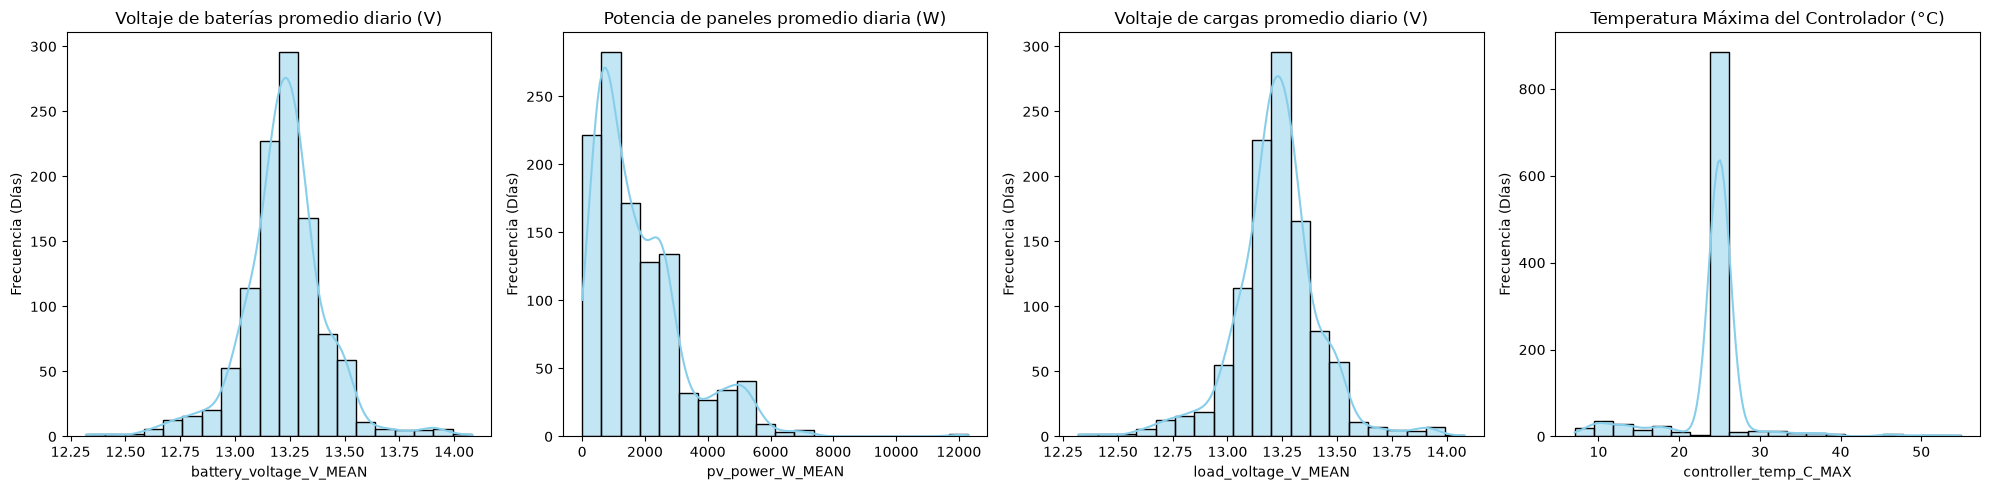

In [15]:
variables_hist = {
    'battery_voltage_V_MEAN': 'Voltaje de baterías promedio diario (V)',
    'pv_power_W_MEAN': 'Potencia de paneles promedio diaria (W)',
    'load_voltage_V_MEAN': 'Voltaje de cargas promedio diario (V)',
    'controller_temp_C_MAX': 'Temperatura Máxima del Controlador (°C)'
}

plt.figure(figsize=(20, 5))
for i, (col, titulo) in enumerate(variables_hist.items(), 1):
    if col in df_diario.columns:
        plt.subplot(1, 4, i)
        sns.histplot(df_diario[col], bins=20, kde=True, color='skyblue')
        plt.title(titulo)
        plt.xlabel(col)
        plt.ylabel('Frecuencia (Días)')
        
plt.tight_layout()
plt.show()


## Normalización Min-Max 

Escalamos variables que tienen rangos muy distintos (como voltaje, corriente y potencia).

In [12]:
# Verificar cantidad de valores nulos antes del rellenado
print("🔍 Valores nulos por columna antes del forward fill:\n")
print(df_estaciones.isnull().sum())

# Rellenar valores nulos con forward fill
df_estaciones[df_estaciones.columns] = df_estaciones.groupby('station_name')[df_estaciones.columns].ffill()

# Definir columnas *_MEAN para normalizar
cols_to_scale = [
    'pv_voltage_V', 
    'pv_current_A', 
    'pv_power_W', 
    'battery_voltage_V', 
    'battery_current_A', 
    'battery_soc_%', 
    'controller_temp_C', 
    'load_current_A', 
    'load_power_W', 
    'load_voltage_V'
]

# Aplicar normalización Min-Max y mostrar ejemplos
for col in cols_to_scale:
    
    min_val_serie = df_estaciones.groupby('station_name')[col].transform('min')
    max_val_serie = df_estaciones.groupby('station_name')[col].transform('max')
    
    df_estaciones[col + '_NORM'] = (df_estaciones[col] - min_val_serie) / (max_val_serie - min_val_serie)
    
    resumen_min_max = df_estaciones.groupby('station_name')[col].agg(['min', 'max']).head(3) # Muestra las primeras 3 estaciones
    
    print(f"\n🔹 Normalización de {col}:")
    print("   Ejemplo de valores base:")
    print(resumen_min_max)
    print("   Muestra de resultados:")
    display(df_estaciones[['station_name', col, col + '_NORM']].head(5))

🔍 Valores nulos por columna antes del forward fill:

station_name                     0
timestamp                        0
pv_voltage_V                   219
pv_current_A                   305
pv_power_W                     383
battery_voltage_V              379
battery_current_A              403
battery_soc_%                  464
controller_temp_C              541
charging_status                573
load_current_A                 628
load_power_W                   662
energy_generated_today_kWh     668
energy_consumed_today_kWh      691
battery_voltage_max_today_V    722
battery_voltage_min_today_V    725
energy_total_generated_kWh     773
load_voltage_V                 294
fecha                            0
hora                             0
minuto                           0
dtype: int64

🔹 Normalización de pv_voltage_V:
   Ejemplo de valores base:
              min    max
station_name            
AguasAgrias   0.0  50.39
Anganoy       0.0  44.48
Arles         0.0  44.31
   Muestra d

,station_name,pv_voltage_V,pv_voltage_V_NORM
0,AguasAgrias,20.56,0.408017
1,AguasAgrias,21.14,0.419528
2,AguasAgrias,21.94,0.435404
3,AguasAgrias,19.83,0.393530
4,AguasAgrias,21.59,0.428458



🔹 Normalización de pv_current_A:
   Ejemplo de valores base:
              min   max
station_name           
AguasAgrias   0.0  2.11
Anganoy       0.0  1.92
Arles         0.0  4.06
   Muestra de resultados:


,station_name,pv_current_A,pv_current_A_NORM
0,AguasAgrias,1.50,0.710900
1,AguasAgrias,1.22,0.578199
2,AguasAgrias,1.11,0.526066
3,AguasAgrias,1.31,0.620853
4,AguasAgrias,1.38,0.654028



🔹 Normalización de pv_power_W:
   Ejemplo de valores base:
              min      max
station_name              
AguasAgrias   0.0   3931.0
Anganoy       0.0   6756.0
Arles         0.0  10794.0
   Muestra de resultados:


...

,station_name,load_current_A,load_current_A_NORM
0,AguasAgrias,0.86,1.000000
1,AguasAgrias,0.73,0.833333
2,AguasAgrias,0.71,0.807692
3,AguasAgrias,0.69,0.782051
4,AguasAgrias,0.64,0.717949



🔹 Normalización de load_power_W:
   Ejemplo de valores base:
                min     max
station_name               
AguasAgrias   109.0  1167.0
Anganoy       281.0   452.0
Arles         283.0   681.0
   Muestra de resultados:


,station_name,load_power_W,load_power_W_NORM
0,AguasAgrias,1167.0,1.000000
1,AguasAgrias,1116.0,0.951796
2,AguasAgrias,1033.0,0.873346
3,AguasAgrias,1033.0,0.873346
4,AguasAgrias,897.0,0.744802



🔹 Normalización de load_voltage_V:
   Ejemplo de valores base:
                min    max
station_name              
AguasAgrias   12.79  14.78
Anganoy        0.00  14.77
Arles         12.75  15.05
   Muestra de resultados:


,station_name,load_voltage_V,load_voltage_V_NORM
0,AguasAgrias,14.59,0.904523
1,AguasAgrias,14.52,0.869347
2,AguasAgrias,14.55,0.884422
3,AguasAgrias,14.56,0.889447
4,AguasAgrias,14.71,0.964824


In [17]:
# Guardar en capa Plata

path_diario = PLATA_DIR / 'dataset_minmax.csv'
df_estaciones.to_csv(path_diario, index=False)

In [18]:
# Agrupar por estación y fecha
df_diario_minmax = df_estaciones.groupby(['station_name', 'fecha']).agg({
    'pv_voltage_V_NORM': ['mean', 'min', 'max'],            
    'pv_current_A_NORM': ['mean', 'min', 'max'],
    'pv_power_W_NORM': ['mean', 'min', 'max'],
    'battery_soc_%_NORM': ['mean', 'min', 'max'],          
    'battery_voltage_V_NORM': ['mean', 'min', 'max'], 
    'battery_current_A_NORM': ['mean', 'min', 'max'],
    'load_voltage_V_NORM': ['mean', 'min', 'max'],
    'load_current_A_NORM': ['mean', 'min', 'max'],
    'load_power_W_NORM': ['mean', 'min', 'max'],
    'controller_temp_C_NORM': ['mean', 'min', 'max'],      
    'energy_generated_today_kWh': ['max'],     
    'energy_consumed_today_kWh': ['max']       
})

# Aplanar los niveles de las columnas
df_diario_minmax.columns = [f"{col[0]}_{col[1].upper()}" for col in df_diario_minmax.columns]
df_diario_minmax = df_diario_minmax.reset_index()

print("Muestra del dataset agrupado por día:")
display(df_diario_minmax.head())

Muestra del dataset agrupado por día:


,station_name,fecha,pv_voltage_V_NORM_MEAN,pv_voltage_V_NORM_MIN,pv_voltage_V_NORM_MAX,pv_current_A_NORM_MEAN,pv_current_A_NORM_MIN,pv_current_A_NORM_MAX,pv_power_W_NORM_MEAN,pv_power_W_NORM_MIN,...,load_current_A_NORM_MIN,load_current_A_NORM_MAX,load_power_W_NORM_MEAN,load_power_W_NORM_MIN,load_power_W_NORM_MAX,controller_temp_C_NORM_MEAN,controller_temp_C_NORM_MIN,controller_temp_C_NORM_MAX,energy_generated_today_kWh_MAX,energy_consumed_today_kWh_MAX
0,AguasAgrias,2026-05-12,0.326540,0.0,0.946219,0.094350,0.0,0.710900,0.122890,0.0,...,0.038462,1.000000,0.144650,0.043478,1.000000,0.416160,0.189924,0.717713,0.13,0.06
1,AguasAgrias,2026-05-13,0.219940,0.0,0.946219,0.109985,0.0,0.772512,0.128834,0.0,...,0.025641,0.166667,0.088521,0.043478,0.140832,0.334308,0.161136,0.908037,0.05,0.03
2,AguasAgrias,2026-05-14,0.433481,0.0,0.959714,0.043281,0.0,0.355450,0.087098,0.0,...,0.000000,0.166667,0.083106,0.031191,0.132325,0.523132,0.190324,0.969612,0.08,0.05
3,AguasAgrias,2026-05-15,0.343116,0.0,0.972415,0.052930,0.0,0.554502,0.082125,0.0,...,0.025641,0.153846,0.089736,0.014178,0.142722,0.425806,0.185126,0.861655,0.08,0.05
4,AguasAgrias,2026-05-16,0.283990,0.0,0.938480,0.071887,0.0,0.819905,0.089454,0.0,...,0.038462,0.166667,0.094129,0.040643,0.146503,0.359636,0.185126,0.657337,0.08,0.04


In [19]:
# Guardar en capa Plata

path_diario = PLATA_DIR / 'dataset_diario_minmax.csv'
df_diario_minmax.to_csv(path_diario, index=False)

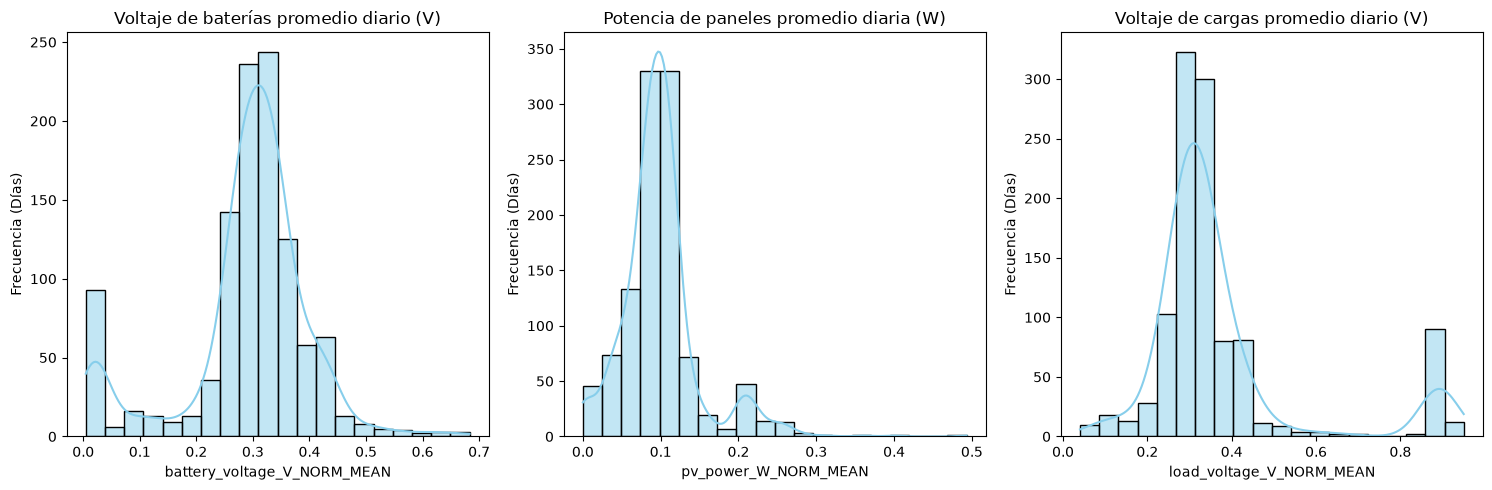

In [21]:
variables_hist = {
    'battery_voltage_V_NORM_MEAN': 'Voltaje de baterías promedio diario (V)',
    'pv_power_W_NORM_MEAN': 'Potencia de paneles promedio diaria (W)',
    'load_voltage_V_NORM_MEAN': 'Voltaje de cargas promedio diario (V)',
    'controller_temp_MAX': 'Temperatura Máxima del Controlador (°C)'
}

plt.figure(figsize=(20, 5))
for i, (col, titulo) in enumerate(variables_hist.items(), 1):
    if col in df_diario_minmax.columns:
        plt.subplot(1, 4, i)
        sns.histplot(df_diario_minmax[col], bins=20, kde=True, color='skyblue')
        plt.title(titulo)
        plt.xlabel(col)
        plt.ylabel('Frecuencia (Días)')
        
plt.tight_layout()
plt.show()

## Informe final de capa

In [23]:
df_estaciones.info()

<class 'pandas.DataFrame'>
Index: 106386 entries, 0 to 106871
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   station_name                 106386 non-null  str           
 1   timestamp                    106386 non-null  datetime64[us]
 2   pv_voltage_V                 106385 non-null  float64       
 3   pv_current_A                 106385 non-null  float64       
 4   pv_power_W                   106385 non-null  float64       
 5   battery_voltage_V            106385 non-null  float64       
 6   battery_current_A            106385 non-null  float64       
 7   battery_soc_%                106386 non-null  float64       
 8   controller_temp_C            106385 non-null  float64       
 9   charging_status              106385 non-null  float64       
 10  load_current_A               106384 non-null  float64       
 11  load_power_W                 106384 non-nu

In [24]:
df_diario.info()

<class 'pandas.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype        
---  ------                          --------------  -----        
 0   station_name                    1092 non-null   str          
 1   fecha                           1092 non-null   datetime64[s]
 2   pv_voltage_V_MEAN               1092 non-null   float64      
 3   pv_voltage_V_MIN                1092 non-null   float64      
 4   pv_voltage_V_MAX                1092 non-null   float64      
 5   pv_current_A_MEAN               1092 non-null   float64      
 6   pv_current_A_MIN                1092 non-null   float64      
 7   pv_current_A_MAX                1092 non-null   float64      
 8   pv_power_W_MEAN                 1092 non-null   float64      
 9   pv_power_W_MIN                  1092 non-null   float64      
 10  pv_power_W_MAX                  1092 non-null   float64      
 11  battery_soc_%_MEAN          

In [25]:
df_diario_minmax.info()

<class 'pandas.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype        
---  ------                          --------------  -----        
 0   station_name                    1092 non-null   str          
 1   fecha                           1092 non-null   datetime64[s]
 2   pv_voltage_V_NORM_MEAN          1092 non-null   float64      
 3   pv_voltage_V_NORM_MIN           1092 non-null   float64      
 4   pv_voltage_V_NORM_MAX           1092 non-null   float64      
 5   pv_current_A_NORM_MEAN          1092 non-null   float64      
 6   pv_current_A_NORM_MIN           1092 non-null   float64      
 7   pv_current_A_NORM_MAX           1092 non-null   float64      
 8   pv_power_W_NORM_MEAN            1092 non-null   float64      
 9   pv_power_W_NORM_MIN             1092 non-null   float64      
 10  pv_power_W_NORM_MAX             1092 non-null   float64      
 11  battery_soc_%_NORM_MEAN     

## Exportación a Capa Plata y generación de metadatos

In [26]:
def generar_metadatos(df):
    metadatos = []
    for col in df.columns:
        serie = df[col]
        metadatos.append({
            "Columna": col,
            "Tipo": str(serie.dtype),
            "No_Nulos": serie.count(),
            "Valores_Unicos": serie.nunique(),
            "Ejemplo": serie.dropna().iloc[0] if not serie.dropna().empty else None
        })
    return pd.DataFrame(metadatos)

if not df_estaciones.empty:
    # Exportar Dataset Base 
    path_base = PLATA_DIR / 'dataset_plata.csv'
    df_estaciones.to_csv(path_base, index=False)
    
    # Exportar Dataset Diario Agrupado 
    path_diario = PLATA_DIR / 'dataset_plata_diario.csv'
    df_diario_minmax.to_csv(path_diario, index=False)
    
    # Metadatos
    df_metadatos = generar_metadatos(df_estaciones)
    df_metadatos.to_csv(PLATA_DIR / 'metadatos.csv', index=False)
    
    print(f"\n Archivos exportados en Capa Plata:")
    print(f" - {path_base}")
    print(f" - {path_diario}")
    print(f" - {PLATA_DIR / 'metadatos_variables.csv'}")



 Archivos exportados en Capa Plata:
 - /Users/andavaro/Documents/Andrés/MCB/GVD/data/plata/dataset_plata.csv
 - /Users/andavaro/Documents/Andrés/MCB/GVD/data/plata/dataset_plata_diario.csv
 - /Users/andavaro/Documents/Andrés/MCB/GVD/data/plata/metadatos_variables.csv


# Conclusión

Durante esta fase construimos la **Capa Plata** del pipeline de datos aplicando buenas prácticas de limpieza y exploración sobre el dataset de variables de sistema eléctrico fotovoltáico. Logramos:

- Tratar valores nulos derivados de interrupciones de lectura.
- Formatear y ordenar correctamente la variable temporal (`timestamp`).
- Generar agrupaciones diarias útiles para análisis posteriores.
- Verificar distribuciones y escalar variables operativas.
- Exportar datasets estructurados para su consumo en modelos analíticos en la Capa Oro.